In [71]:
import torch

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

In [72]:
class perceptron():

    def __init__(self, n_inputs, n_outputs):

        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.threshold = 0
        self.weights = []

        for i in range(self.n_outputs):

            self.weights.append(
                torch.zeros(
                    (n_inputs + 1, 1),
                    dtype=torch.float32
                )
            )


    def forward(self, x):

        output = []

        for i in range(self.n_outputs):

            if torch.matmul(x, self.weights[i]).item() > self.threshold:

                output_prev = 1

            elif torch.matmul(x, self.weights[i]).item() < -self.threshold:

                output_prev = -1

            else:

                output_prev = 0

            output.append(output_prev)

        return torch.tensor(output)


    def train(
        self,
        traindataloader,
        learning_rate=1,
        threshold=1,
        max_epochs=1000
    ):

        self.learning_rate = learning_rate
        self.threshold = threshold

        stop_condition = False
        epochs = 0

        while not stop_condition and epochs < max_epochs:

            print("epochs", epochs)

            stop_condition = True

            for img, labels in iter(traindataloader):

                img_b = 2 * ((img > 0.5) * 1.0) - 1

                t = torch.tensor([-1.0, -1.0, -1.0])

                x_1 = torch.concat(
                    [
                        torch.ones(1),
                        img_b.flatten()
                    ]
                ).unsqueeze(axis=0)

                t[labels.item()] = 1

                y = self.forward(x_1)

                for i in range(self.n_outputs):

                    if y[i].item() != t[i].item():

                        self.weights[i][1:] = (
                            self.weights[i][1:]
                            + self.learning_rate
                            * torch.transpose(x_1, 0, 1)[1:]
                            * t[i]
                        )

                        self.weights[i][0] = (
                            self.weights[i][0]
                            + self.learning_rate
                            * t[i]
                        )

                        stop_condition = False

            epochs += 1

        print("Total de épocas:", epochs)

In [73]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [74]:
train_directory = "dataset_char_rec/train/"
test_directory = "dataset_char_rec/test/"

In [75]:
transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [76]:
train_dataset = ImageFolder(
    train_directory,
    transform_train
)

test_dataset = ImageFolder(
    test_directory,
    transform_test
)

In [77]:
print(train_dataset)
print(test_dataset)

print(train_dataset.classes)
print(train_dataset.class_to_idx)

Dataset ImageFolder
    Number of datapoints: 30
    Root location: dataset_char_rec/train/
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )
Dataset ImageFolder
    Number of datapoints: 30
    Root location: dataset_char_rec/test/
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )
['A', 'B', 'C']
{'A': 0, 'B': 1, 'C': 2}


In [78]:
print(train_dataset[0])
print(train_dataset[0][0].shape)

(tensor([[[1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 0., 0., 0., 1., 1., 1.],
         [1., 1., 0., 1., 0., 0., 1., 1.],
         [1., 0., 0., 1., 1., 0., 0., 1.],
         [1., 0., 1., 1., 1., 1., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 1., 1., 1., 1., 1., 0.],
         [0., 1., 1., 1., 1., 1., 1., 1.]]]), 0)
torch.Size([1, 8, 8])


In [79]:
2 * ((train_dataset[0][0] > 0.5) * 1.0) - 1

tensor([[[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
         [ 1.,  1., -1., -1., -1.,  1.,  1.,  1.],
         [ 1.,  1., -1.,  1., -1., -1.,  1.,  1.],
         [ 1., -1., -1.,  1.,  1., -1., -1.,  1.],
         [ 1., -1.,  1.,  1.,  1.,  1., -1.,  1.],
         [-1., -1., -1., -1., -1., -1., -1., -1.],
         [-1.,  1.,  1.,  1.,  1.,  1.,  1., -1.],
         [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.]]])

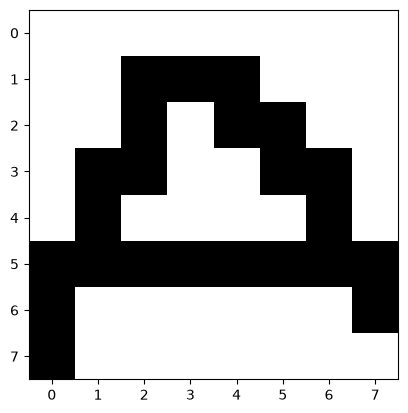

In [80]:
plt.imshow(
    train_dataset[0][0].permute(dims=[1, 2, 0]),
    cmap="gray"
)

plt.show()

In [81]:
BATCH_SIZE = 1

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [82]:
Perceptron1 = perceptron(
    n_inputs=64,
    n_outputs=3
)

In [83]:
Perceptron1.train(
    train_dataloader,
    learning_rate=0.01
)

epochs 0
epochs 1
epochs 2
epochs 3
epochs 4
epochs 5
epochs 6
epochs 7
epochs 8
epochs 9
epochs 10
epochs 11
Total de épocas: 12


In [84]:
img, label = test_dataset[0]

img_b = 2 * ((img > 0.5) * 1.0) - 1

x_1 = torch.concat(
    [
        torch.ones(1),
        img_b.flatten()
    ]
).unsqueeze(axis=0)

output = Perceptron1.forward(x_1)

print("Salida:", output)

print(
    "Clase real:",
    test_dataset.classes[label]
)

print(
    "Predicción:",
    test_dataset.classes[torch.argmax(output)]
)

Salida: tensor([ 0,  0, -1])
Clase real: A
Predicción: A


In [85]:
correctas = 0

for img, label in test_dataloader:

    img_b = 2 * ((img > 0.5) * 1.0) - 1

    x_1 = torch.concat(
        [
            torch.ones(1),
            img_b.flatten()
        ]
    ).unsqueeze(axis=0)

    output = Perceptron1.forward(x_1)

    prediccion = torch.argmax(output).item()

    print(
        "Real:",
        test_dataset.classes[label.item()],
        "| Predicción:",
        test_dataset.classes[prediccion]
    )

    if prediccion == label.item():

        correctas += 1


print("Correctas:", correctas)
print("Total:", len(test_dataset))

print(
    "Exactitud:",
    correctas / len(test_dataset) * 100,
    "%"
)

Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: B
Real: A | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: C
Real: B | Predicción: A
Real: B | Predicción: B
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: B
Real: C | Predicción: C
Real: C | Predicción: C
Real: C | Predicción: A
Real: C | Predicción: C
Real: C | Predicción: A
Real: C | Predicción: C
Real: C | Predicción: A
Real: C | Predicción: C
Real: C | Predicción: C
Real: C | Predicción: A
Correctas: 17
Total: 30
Exactitud: 56.666666666666664 %


In [86]:
data = (
    Perceptron1.weights[0][1:]
    + Perceptron1.weights[0][0]
)

minval = min(data)

data = data - minval

maxval = max(data)

if maxval.item() != 0:

    data = data / maxval

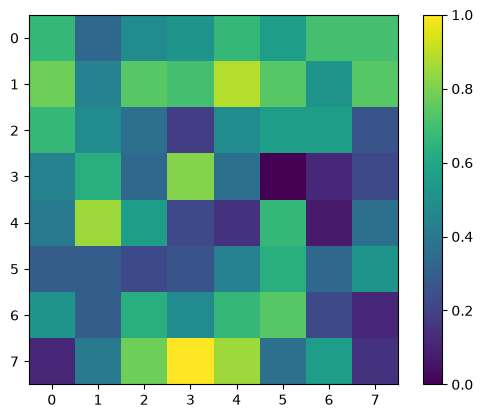

In [87]:
plt.imshow(
    data.reshape((8, 8))
)

plt.colorbar()
plt.show()